# Circularised endpoint geometry for exact-flow NUTS

This notebook compares the ordinary endpoint criterion with a trajectory-dependent circularising metric for an isotropic Gaussian target.

The matrix is computed once from $(x_0,p_0)$ and kept fixed throughout the complete NUTS tree. Exact circularisation requires
$\operatorname{rank}(x_0,\sigma p_0)=2$, so the radius grid must exclude $\|x_0\|=0$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def circularising_metric(x0, p0, sigma=1.0, m=1.0, eta=1.0, rank_rtol=1e-12):
    """
    Construct the canonical circularising metric

        W = m Z0 G^{-2} Z0^T + eta (I_d - P),

    where

        Z0 = (x0, sigma p0),
        G  = Z0^T Z0,
        P  = Z0 G^{-1} Z0^T.

    The inverse matrices G^{-1} and G^{-2} are computed through the
    eigendecomposition of the symmetric positive-definite matrix G.

    Parameters
    ----------
    x0, p0 : ndarray, shape (d,)
        Initial position and momentum.

    sigma : float, default=1.0
        Standard deviation of the isotropic Gaussian target.

    m : float, default=1.0
        Squared radius of the transformed circular trajectory.
        Any m > 0 is permitted.

    eta : float, default=1.0
        Positive weight assigned to the orthogonal complement of
        span{x0, p0}.

    rank_rtol : float, default=1e-12
        Relative tolerance used to determine whether G is numerically
        singular.

    Returns
    -------
    W : ndarray, shape (d, d)
        Symmetric positive-definite circularising metric.

    diagnostics : dict
        Intermediate quantities and numerical verification results.
    """
    x0 = np.asarray(x0, dtype=float)
    p0 = np.asarray(p0, dtype=float)

    # --------------------------------------------------------
    # Input checks
    # --------------------------------------------------------
    if x0.ndim != 1 or p0.ndim != 1:
        raise ValueError("x0 and p0 must be one-dimensional arrays.")

    if x0.shape != p0.shape:
        raise ValueError("x0 and p0 must have the same dimension.")

    if sigma <= 0:
        raise ValueError("sigma must be positive.")

    if m <= 0:
        raise ValueError("m must be positive.")

    if eta <= 0:
        raise ValueError("eta must be positive.")

    d = x0.size

    # --------------------------------------------------------
    # Construct Z0 and G = Z0^T Z0
    # --------------------------------------------------------
    Z0 = np.column_stack((x0, sigma * p0))
    G = Z0.T @ Z0

    # --------------------------------------------------------
    # Eigendecomposition of G
    #
    # Since G is symmetric:
    #     G = V diag(lambda) V^T
    # --------------------------------------------------------
    eigenvalues_G, eigenvectors_G = np.linalg.eigh(G)

    largest_eigenvalue = eigenvalues_G[-1]
    smallest_eigenvalue = eigenvalues_G[0]

    if largest_eigenvalue <= 0:
        raise np.linalg.LinAlgError(
            "G is not positive definite. Check x0, p0 and sigma."
        )

    if smallest_eigenvalue <= rank_rtol * largest_eigenvalue:
        raise np.linalg.LinAlgError(
            "G is singular or numerically nearly singular. "
            "Exact circularisation requires x0 and p0 to be linearly independent."
        )

    # --------------------------------------------------------
    # Calculate G^{-1} and G^{-2}
    # --------------------------------------------------------
    G_inv = (
        eigenvectors_G
        @ np.diag(1.0 / eigenvalues_G)
        @ eigenvectors_G.T
    )

    G_inv_squared = (
        eigenvectors_G
        @ np.diag(1.0 / eigenvalues_G**2)
        @ eigenvectors_G.T
    )

    # Equivalently:
    # G_inv_squared = G_inv @ G_inv

    # --------------------------------------------------------
    # Orthogonal projection onto span{x0, p0}
    # --------------------------------------------------------
    P = Z0 @ G_inv @ Z0.T

    # Remove negligible numerical asymmetry
    P = 0.5 * (P + P.T)

    # --------------------------------------------------------
    # Construct W
    # --------------------------------------------------------
    W_parallel = m * Z0 @ G_inv_squared @ Z0.T  # components that are parallel to orbit subspace (from Q1)
    W_perpendicular = eta * (np.eye(d) - P)  # components that are perpendicular to orbit subspace (from Q2)

    W = W_parallel + W_perpendicular

    # Remove negligible numerical asymmetry
    W = 0.5 * (W + W.T)

    # --------------------------------------------------------
    # Numerical diagnostics
    # --------------------------------------------------------
    target_matrix = m * np.eye(2)

    circularisation_error = np.linalg.norm(
        Z0.T @ W @ Z0 - target_matrix
    )

    projection_error = np.linalg.norm(P @ P - P)

    symmetry_error_W = np.linalg.norm(W - W.T)

    eigenvalues_W = np.linalg.eigvalsh(W)

    diagnostics = {
        "Z0": Z0,
        "G": G,
        "G_eigenvalues": eigenvalues_G,
        "G_eigenvectors": eigenvectors_G,
        "G_inv": G_inv,
        "G_inv_squared": G_inv_squared,
        "P": P,
        "W_parallel": W_parallel,
        "W_perpendicular": W_perpendicular,
        "minor_axis_squared": smallest_eigenvalue,
        "circularisation_error": circularisation_error,
        "projection_error": projection_error,
        "symmetry_error_W": symmetry_error_W,
        "eigenvalues_W": eigenvalues_W,
        "m": float(m),
        "eta": float(eta),
    }

    return W, diagnostics

In [3]:
x0 = np.array([1.0, 0.0, 0.0])
rng = np.random.default_rng(seed=0)
p0 = rng.normal(loc=0.0, scale=1.0, size=x0.shape)

W, diagnostics = circularising_metric(x0, p0, sigma=1.0, m=1.0, eta=1.0, rank_rtol=1e-12)

In [4]:
class ExactFlowNUTS_MultiD_Gaussian:
    """
    Exact-flow NUTS tree simulator for the d-dimensional Gaussian target

        pi(x) = N(0, Sigma),   A = Sigma^{-1}.

    Hamiltonian:

        H(x,p) = 1/2 x^T A x + 1/2 p^T p.

    Exact flow:

        x(t) = cos(t A^{1/2}) x0
               + A^{-1/2} sin(t A^{1/2}) p0,

        p(t) = - A^{1/2} sin(t A^{1/2}) x0
               + cos(t A^{1/2}) p0.

    This keeps the Hoffman-Gelman random doubling construction,
    but replaces leapfrog integration by the exact Gaussian Hamiltonian flow.

    We record

        K_star = number of successful completed full-tree doublings
                 before stopping.

    In addition, this version records the first failed NUTS block and uses
    the failing endpoint(s) of that block to define an observed U-turn index.
    """

    def __init__(self, A=None, Sigma=None, epsilon=0.1, rng=None, tol=1e-12):
        """
        Parameters
        ----------
        A : np.ndarray, shape (d,d)
            Precision matrix A = Sigma^{-1}. Must be symmetric positive definite.

        Sigma : np.ndarray, shape (d,d)
            Covariance matrix. If A is not supplied, A = inv(Sigma).

        epsilon : float
            Grid step size.

        rng : np.random.Generator or None
            Random number generator.

        tol : float
            Numerical tolerance used in U-turn comparisons.
        """

        if A is None and Sigma is None:
            raise ValueError("Please provide either A or Sigma.")

        if A is not None and Sigma is not None:
            raise ValueError("Please provide only one of A or Sigma, not both.")

        if Sigma is not None:
            Sigma = np.asarray(Sigma, dtype=float)
            A = np.linalg.inv(Sigma)
        else:
            A = np.asarray(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("A must be a square matrix.")

        # Symmetrise for numerical safety
        A = 0.5 * (A + A.T)

        eigvals, eigvecs = np.linalg.eigh(A)

        if np.any(eigvals <= 0):
            raise ValueError("A must be positive definite.")

        self.A = A
        self.eigvals = eigvals
        self.eigvecs = eigvecs
        self.sqrt_eigvals = np.sqrt(eigvals)

        self.d = A.shape[0]
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng
        self.tol = tol

    # ------------------------------------------------------------
    # Matrix-function-vector products
    # ------------------------------------------------------------
    def _cos_sqrtA_times(self, t, v):
        """
        Compute cos(t A^{1/2}) v using the eigendecomposition of A.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = np.cos(t * lam_sqrt) * v_hat

        return Q @ out_hat

    def _invsqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{-1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = (np.sin(t * lam_sqrt) / lam_sqrt) * v_hat

        return Q @ out_hat

    def _sqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = lam_sqrt * np.sin(t * lam_sqrt) * v_hat

        return Q @ out_hat

    # ------------------------------------------------------------
    # Exact Hamiltonian state
    # ------------------------------------------------------------
    def state(self, n, x0, p0):
        """
        Exact Hamiltonian state at grid index n, i.e. time t = n epsilon.

        Returns
        -------
        x_n : np.ndarray, shape (d,)
        p_n : np.ndarray, shape (d,)
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        t = n * self.epsilon

        x_n = (
            self._cos_sqrtA_times(t, x0)
            + self._invsqrtA_sin_sqrtA_times(t, p0)
        )

        p_n = (
            -self._sqrtA_sin_sqrtA_times(t, x0)
            + self._cos_sqrtA_times(t, p0)
        )

        return x_n, p_n

    # ------------------------------------------------------------
    # Hamiltonian, useful for checking exact energy conservation
    # ------------------------------------------------------------
    def Hamiltonian(self, x, p):
        """
        Compute H(x,p) = 1/2 x^T A x + 1/2 p^T p.
        """
        x = np.asarray(x, dtype=float)
        p = np.asarray(p, dtype=float)

        return 0.5 * x @ self.A @ x + 0.5 * p @ p

    # ------------------------------------------------------------
    # Multidimensional no-U-turn criterion with diagnostics
    # ------------------------------------------------------------
    def Uturn_info(self, a, b, x0, p0):
        """
        Return detailed information for the multidimensional endpoint
        no-U-turn test on the block [a,b].

        The block is NUTS-valid iff

            (x_b - x_a)^T p_a >= 0,

        and

            (x_b - x_a)^T p_b >= 0.

        If either endpoint inner product is negative, the block makes a U-turn.

        Returns
        -------
        info : dict
            Dictionary containing:
                valid : bool
                block : tuple[int, int]
                left_test : float
                right_test : float
                fail_left : bool
                fail_right : bool
                failing_endpoints : list[int]
        """

        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        left_test = np.dot(dx, p_a)
        right_test = np.dot(dx, p_b)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []

        if fail_left:
            failing_endpoints.append(a)

        if fail_right:
            failing_endpoints.append(b)

        valid = not (fail_left or fail_right)

        return {
            "valid": valid,
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }

    def no_Uturn(self, a, b, x0, p0):
        """
        Boolean version of the multidimensional endpoint no-U-turn test.
        """

        return self.Uturn_info(a, b, x0, p0)["valid"]

    def observed_index_from_failed_info(
        self,
        failed_info,
        new_indices=None,
        direction=None,
        current_left=None,
        current_right=None
    ):
        """
        Given the first failed proposed doubling, return the newly generated
        index closest to time 0.

        This defines the observed U-turn index as

            k_obs = argmin_{k in new_indices} |k|,

        where new_indices are the indices generated in the failed proposed subtree.

        This is a one-direction observed U-turn diagnostic: it records the first
        newly generated grid point, in time magnitude, belonging to the failed
        proposed doubling. It does not compare the trajectory with index 0, and it
        does not use the far endpoint of the failed dyadic block.

        Parameters
        ----------
        failed_info : dict or None
            Diagnostic information for the first failed NUTS block.

        new_indices : list[int] or None
            Indices generated in the failed proposed subtree.

        direction : int or None
            Direction of the failed doubling, either -1 or +1.
            This argument is not needed for the current definition but is kept
            for compatibility.

        current_left : int or None
            Left endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        current_right : int or None
            Right endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        Returns
        -------
        observed_uturn_index : int or None
            The newly generated index with smallest absolute value.
        """

        if failed_info is None:
            return None

        if new_indices is None:
            return None

        new_indices = list(new_indices)

        if len(new_indices) == 0:
            return None

        return min(new_indices, key=lambda k: abs(k))

    # ------------------------------------------------------------
    # Tree building
    # ------------------------------------------------------------
    def build_tree(self, start_index, direction, depth, x0, p0):
        """
        Build a subtree of depth `depth` starting from `start_index`
        in the given direction.

        This function recursively checks all balanced subtrees. If a U-turn
        is detected, it returns the first failed block diagnostic.

        Parameters
        ----------
        start_index : int
            Starting grid index.

        direction : int
            Either -1 or +1.

        depth : int
            Tree depth.

        x0, p0 : np.ndarray
            Initial position and momentum.

        Returns
        -------
        left : int
            Leftmost grid index of the newly built subtree.

        right : int
            Rightmost grid index of the newly built subtree.

        indices : list[int]
            All newly generated grid indices in this subtree.

        valid : bool
            Whether every balanced subtree inside this newly built subtree
            passes the NUTS endpoint test.

        failed_info : dict or None
            Diagnostic information for the first failed block.
        """

        if direction not in [-1, 1]:
            raise ValueError("direction must be either -1 or +1.")

        if depth < 0:
            raise ValueError("depth must be non-negative.")

        # Base case: one leap in the chosen direction
        if depth == 0:
            new_index = start_index + direction
            return new_index, new_index, [new_index], True, None

        # ------------------------------------------------------------
        # 1. Build first half-subtree
        # ------------------------------------------------------------
        left, right, indices, valid, failed_info = self.build_tree(
            start_index, direction, depth - 1, x0, p0
        )

        if not valid:
            return left, right, indices, False, failed_info

        # ------------------------------------------------------------
        # 2. Build second half-subtree
        # ------------------------------------------------------------
        if direction == -1:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                left, direction, depth - 1, x0, p0
            )

            left = left2
            indices = indices2 + indices

        else:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                right, direction, depth - 1, x0, p0
            )

            right = right2
            indices = indices + indices2

        if not valid2:
            return left, right, indices, False, failed_info2

        # ------------------------------------------------------------
        # 3. Check the full newly built balanced subtree
        # ------------------------------------------------------------
        info = self.Uturn_info(left, right, x0, p0)

        if not info["valid"]:
            return left, right, indices, False, info

        return left, right, indices, True, None
    
    def one_tree(self, x0, p0, max_depth=20, return_sample=True):
        """
        Generate one exact-flow NUTS tree from fixed (x0,p0).

        This version keeps the candidate set C NUTS-valid.

        If the proposed enlarged tree fails, the newly built subtree is
        rejected and not added to C. The first failed block is recorded.

        The observed U-turn index is chosen from the newly generated part
        of the failed doubling, rather than from an old endpoint of the
        retained tree.

        Returns
        -------
        result : dict
            Contains K_star, retained endpoints, failed endpoints,
            first failed block information, observed U-turn index, and
            optionally a sampled state from the retained candidate set.
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        left = 0
        right = 0

        # Candidate set C.
        # For exact Gaussian Hamiltonian flow, energy is conserved.
        # Hence the slice condition is always satisfied.
        C_indices = [0]

        depth = 0
        K_star = 0

        # Information about the first failed proposed doubling
        failed_left = None
        failed_right = None
        failed_direction = None
        failed_block = None
        failed_info = None
        stop_reason = None
        observed_uturn_index = None

        while depth <= max_depth:
            direction = self.rng.choice([-1, 1])

            # Store the currently retained valid tree before proposing expansion.
            current_left = left
            current_right = right

            # ------------------------------------------------------------
            # 1. Build proposed new subtree, but do not commit it yet
            # ------------------------------------------------------------
            if direction == -1:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(left, direction, depth, x0, p0)
                )

                proposed_left = new_left
                proposed_right = right

            else:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(right, direction, depth, x0, p0)
                )

                proposed_left = left
                proposed_right = new_right

            # ------------------------------------------------------------
            # 2. If proposed subtree itself is invalid, reject it and stop
            # ------------------------------------------------------------
            if not subtree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = subtree_failed_info

                failed_block = (
                    subtree_failed_info["block"]
                    if subtree_failed_info is not None
                    else None
                )

                stop_reason = "subtree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=subtree_failed_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 3. Check whether the enlarged full tree would remain valid
            # ------------------------------------------------------------
            full_tree_info = self.Uturn_info(
                proposed_left,
                proposed_right,
                x0,
                p0
            )

            full_tree_valid = full_tree_info["valid"]

            # ------------------------------------------------------------
            # 4. If enlarged full tree is invalid, reject whole subtree
            # ------------------------------------------------------------
            if not full_tree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = full_tree_info
                failed_block = full_tree_info["block"]
                stop_reason = "full_tree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=full_tree_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 5. Otherwise commit the proposed subtree
            # ------------------------------------------------------------
            C_indices.extend(new_indices)

            left = proposed_left
            right = proposed_right

            K_star += 1
            depth += 1

        # ------------------------------------------------------------
        # Retained-tree time scale
        # ------------------------------------------------------------
        T_ret = max(right, -left) * self.epsilon

        # ------------------------------------------------------------
        # Observed U-turn time
        # ------------------------------------------------------------
        if observed_uturn_index is not None:
            T_obs = abs(observed_uturn_index) * self.epsilon
        else:
            T_obs = np.nan

        # ------------------------------------------------------------
        # Failed proposed tree endpoint scale
        # ------------------------------------------------------------
        if failed_left is not None and failed_right is not None:
            T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
        else:
            T_failed_endpoint = np.nan

        # ------------------------------------------------------------
        # Sample only from the retained NUTS-valid candidate set C
        # ------------------------------------------------------------
        if return_sample:
            chosen_index = self.rng.choice(C_indices)
            x_sample, p_sample = self.state(chosen_index, x0, p0)
        else:
            chosen_index = None
            x_sample = None
            p_sample = None

        return {
            "K_star": K_star,

            # Retained valid tree
            "left": left,
            "right": right,
            "C_indices": C_indices,
            "new_indices": new_indices,

            # Failed proposed tree
            "failed_left": failed_left,
            "failed_right": failed_right,
            "failed_direction": failed_direction,
            "failed_block": failed_block,
            "failed_info": failed_info,
            "stop_reason": stop_reason,

            # Observed U-turn diagnostic
            "observed_uturn_index": observed_uturn_index,
            "T_obs": T_obs,

            # Other time scales
            "T_ret": T_ret,
            "T_failed_endpoint": T_failed_endpoint,

            # Sampled state
            "chosen_index": chosen_index,
            "x_sample": x_sample,
            "p_sample": p_sample,
        }

In [5]:
class ExactFlowNUTS_MultiD_Gaussian_Circularised(
    ExactFlowNUTS_MultiD_Gaussian
):
    """
    Exact-flow NUTS for an isotropic Gaussian target using the
    trajectory-dependent weighted endpoint criterion

        (x_b-x_a)^T W p_a >= 0,
        (x_b-x_a)^T W p_b >= 0,

    where W=W(x0,p0) circularises the exact position orbit.

    The Hamiltonian trajectory itself is unchanged. Only the geometry
    used for detecting U-turns is modified.
    """

    def __init__(self, d, sigma=1.0, epsilon=0.1, m=1.0, eta=1.0, rng=None,
        tol=1e-12, rank_rtol=1e-12
    ):
        """
        Parameters
        ----------
        d : int
            Dimension of the isotropic Gaussian target.

        sigma : float
            Target standard deviation, so Sigma = sigma^2 I_d.

        epsilon : float
            Exact-flow grid spacing.

        m : float
            Squared radius of the transformed circle.

            The value of m does not affect the sign of the weighted
            U-turn criterion, provided m > 0.

        eta : float
            Positive weight on the orthogonal complement of
            span{x0,p0}. In d=2 this term vanishes whenever Z0 has
            rank two.

        rng : np.random.Generator or None
            Random-number generator.

        tol : float
            Tolerance for U-turn comparisons.

        rank_rtol : float
            Relative tolerance for detecting nearly singular G.
        """
        if not isinstance(d, int) or d < 2:
            raise ValueError("d must be an integer with d >= 2.")

        if sigma <= 0:
            raise ValueError("sigma must be positive.")

        if m <= 0 or eta <= 0:
            raise ValueError("m and eta must be positive.")

        self.sigma = float(sigma)
        self.m = float(m)
        self.eta = float(eta)
        self.rank_rtol = float(rank_rtol)

        # Current trajectory-dependent metric
        self.W = None
        self.metric_diagnostics = None
        self._metric_x0 = None
        self._metric_p0 = None

        Sigma = sigma**2 * np.eye(d)  # isotropic Gaussian covariance

        super().__init__(
            Sigma=Sigma,
            epsilon=epsilon,
            rng=rng,
            tol=tol
        )

    # ------------------------------------------------------------
    # Construct W once for the current trajectory
    # ------------------------------------------------------------
    def prepare_metric(self, x0, p0, m=None):
        """
        Construct and store W(x0,p0) for the current NUTS tree.
        """
        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(
                f"x0 and p0 must both have shape ({self.d},)."
            )

        m_used = self.m if m is None else float(m)

        if m_used <= 0:
            raise ValueError("m must be positive.")

        # Compute the circularising metric W and store it for use in U-turn tests
        self.W, self.metric_diagnostics = circularising_metric(
            x0=x0,
            p0=p0,
            sigma=self.sigma,
            m=m_used,
            eta=self.eta,
            rank_rtol=self.rank_rtol
        )

        self._metric_x0 = x0.copy()
        self._metric_p0 = p0.copy()

        return self.W

    def _metric_matches(self, x0, p0):
        """
        Check whether the stored W corresponds to the supplied pair.
        """
        if self.W is None:
            return False

        if self._metric_x0 is None or self._metric_p0 is None:
            return False

        return (
            np.array_equal(np.asarray(x0), self._metric_x0)
            and
            np.array_equal(np.asarray(p0), self._metric_p0)
        )

    # ------------------------------------------------------------
    # Weighted no-U-turn criterion
    # ------------------------------------------------------------
    def Uturn_info(self, a, b, x0, p0):
        """
        Weighted endpoint no-U-turn test on the block [a,b].

        The block is circularised-NUTS-valid iff

            (x_b-x_a)^T W p_a >= 0,

        and

            (x_b-x_a)^T W p_b >= 0.

        The same W=W(x0,p0) is used for every block and subtree
        belonging to the current NUTS tree.
        """
        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        # This fallback makes direct calls to Uturn_info/build_tree safe.
        # During one_tree, W has already been prepared, so this does not
        # repeat the calculation.
        if not self._metric_matches(x0, p0):
            self.prepare_metric(x0, p0)

        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        # Update the weighted inner products for the current block
        left_test = float(dx @ self.W @ p_a)
        right_test = float(dx @ self.W @ p_b)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []

        if fail_left:
            failing_endpoints.append(a)

        if fail_right:
            failing_endpoints.append(b)

        valid = not (fail_left or fail_right)

        return {
            "valid": valid,
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }


    # ------------------------------------------------------------
    # Prepare W once, then use the inherited tree construction
    # ------------------------------------------------------------
    def one_tree(
        self,
        x0,
        p0,
        max_depth=20,
        return_sample=True,
        m=None
    ):
        """
        Generate one circularised exact-flow NUTS tree.

        W(x0,p0) is calculated once before tree construction and is then
        held fixed throughout all full-tree and subtree endpoint tests.
        """
        self.prepare_metric(x0, p0, m=m)

        # This calls the parent's implementation, but all calls to
        # self.Uturn_info use the weighted method above.
        result = super().one_tree(
            x0=x0,
            p0=p0,
            max_depth=max_depth,
            return_sample=return_sample
        )

        # Include metric information in the result.
        result["W"] = self.W.copy()
        result["m"] = self.metric_diagnostics["m"]
        result["metric_diagnostics"] = self.metric_diagnostics
        result["eta"] = self.eta

        return result

In [6]:
# Numerical validation of the transformed endpoint identity
rng_check = np.random.default_rng(123)
x0_check = np.array([2.0, 0.0])
p0_check = rng_check.normal(size=2)

sampler_check = ExactFlowNUTS_MultiD_Gaussian_Circularised(
    d=2, sigma=1.0, epsilon=0.1, m=1.0, eta=1.0,
    rng=np.random.default_rng(321)
)
sampler_check.prepare_metric(x0_check, p0_check)

for a, b in [(-2, 3), (0, 31), (-31, 0)]:
    info = sampler_check.Uturn_info(a, b, x0_check, p0_check)
    analytic = np.sin((b-a) * sampler_check.epsilon / sampler_check.sigma)
    print((a, b), info["left_test"], info["right_test"], analytic)
    assert np.allclose(
        [info["left_test"], info["right_test"]],
        [analytic, analytic],
        atol=1e-10,
    )


(-2, 3) 0.47942553860420767 0.4794255386042162 0.479425538604203
(0, 31) 0.04158066243335734 0.04158066243322878 0.04158066243329049
(-31, 0) 0.04158066243336078 0.041580662433225224 0.04158066243329049


Compare the sampling ability for the naive NUTS and Circularised NUTS, in two aspects:

1. The histogram only for the 1-step samples, with a fixed start as always. A better sampler with faster mixing should cover the target density much wider and swifter.

2. The histogram for total samples with varying, recursive starting point each time. A valid sampler should be able to show the target distribution.

In [7]:
def sampler_eval(method, focus, x0, naive_para, circ_para, n_samples=1000, max_depth=20):
    """
    Evaluate the naive and circularised exact-flow NUTS samplers.

    Parameters
    ----------
    method : str
        Either "naive" or "circularised".

    focus : str
        Either "1-step" or "full".

    naive_para : dict
        Parameters for the naive sampler.
    
    x0 : np.ndarray
        Initial position for the sampler.

    circ_para : dict
        Parameters for the circularised sampler.

    n_samples : int
        Number of samples to generate.

    max_depth : int
        Maximum tree depth.
    """
    if method == "naive":
        sampler = ExactFlowNUTS_MultiD_Gaussian(**naive_para)
    elif method == "circularised":
        sampler = ExactFlowNUTS_MultiD_Gaussian_Circularised(**circ_para)
    else:
        raise ValueError("method must be either 'naive' or 'circularised'.")

    samples = []  # List to store generated samples

    for i in range(n_samples):
        if focus == "1-step":
            p0 = sampler.rng.normal(size=sampler.d)
            sampler_results = sampler.one_tree(x0, p0, max_depth=max_depth)
            samples.append(sampler_results["x_sample"])
        elif focus == "full":
            x0 = x0 if i == 0 else samples[-1]  # Use the last sample as the new x0
            p0 = sampler.rng.normal(size=sampler.d)
            sampler_results = sampler.one_tree(x0, p0, max_depth=max_depth)
            samples.append(sampler_results["x_sample"])

    samples = np.array(samples)
    return samples

In [8]:
def plot_sampler_eval(focus, x0, naive_para, circ_para, n_samples=1000, burn_in=0, max_depth=20):
    """
    Plot the samples from naive and circularised samplers for comparison, 
    and we only focus on the first two dimensions of the samples.

    Parameters
    ----------
    focus : str
        Either "1-step" or "full".

    x0 : np.ndarray
        Initial position for the sampler.

    naive_para : dict
        Parameters for the naive sampler.

    circ_para : dict
        Parameters for the circularised sampler.

    n_samples : int
        Number of samples to generate.

    burn_in : int
        Number of initial samples to discard as burn-in.

    max_depth : int
        Maximum depth for the NUTS sampler.
    """

    if focus == "1-step":
        naive_samples = sampler_eval("naive", "1-step", x0, naive_para, None, n_samples, max_depth)
        circ_samples = sampler_eval("circularised", "1-step", x0, None, circ_para, n_samples, max_depth)

        plt.figure(figsize=(14, 6))
        naive_x = naive_samples[burn_in:, 0]
        naive_y = naive_samples[burn_in:, 1]
        plt.subplot(1, 2, 1)
        plt.hist2d(naive_x, naive_y, bins=100, range=[[-4, 4], [-4, 4]], cmap='RdBu', density=True)
        plt.title("1-step naive exact-flow NUTS samples")

        circ_x = circ_samples[burn_in:, 0]
        circ_y = circ_samples[burn_in:, 1]
        plt.subplot(1, 2, 2)
        plt.hist2d(circ_x, circ_y, bins=100, range=[[-4, 4], [-4, 4]], cmap='RdBu', density=True)
        plt.title("1-step circularised exact-flow NUTS samples")
        plt.show()
        
    elif focus == "full":
        naive_samples = sampler_eval("naive", "full", x0, naive_para, None, n_samples, max_depth)
        circ_samples = sampler_eval("circularised", "full", x0, None, circ_para, n_samples, max_depth)

        plt.figure(figsize=(14, 6))
        naive_x = naive_samples[burn_in:, 0]
        naive_y = naive_samples[burn_in:, 1]
        plt.subplot(1, 2, 1)
        plt.hist2d(naive_x, naive_y, bins=100, range=[[-4, 4], [-4, 4]], cmap='RdBu', density=True)
        plt.title("Full Exact-Flow NUTS samples")

        circ_x = circ_samples[burn_in:, 0]
        circ_y = circ_samples[burn_in:, 1]
        plt.subplot(1, 2, 2)
        plt.hist2d(circ_x, circ_y, bins=100, range=[[-4, 4], [-4, 4]], cmap='RdBu', density=True)
        plt.title("Full Circularised Exact-Flow NUTS samples")
        plt.show()

    else:
        raise ValueError("focus must be either '1-step' or 'full'.")

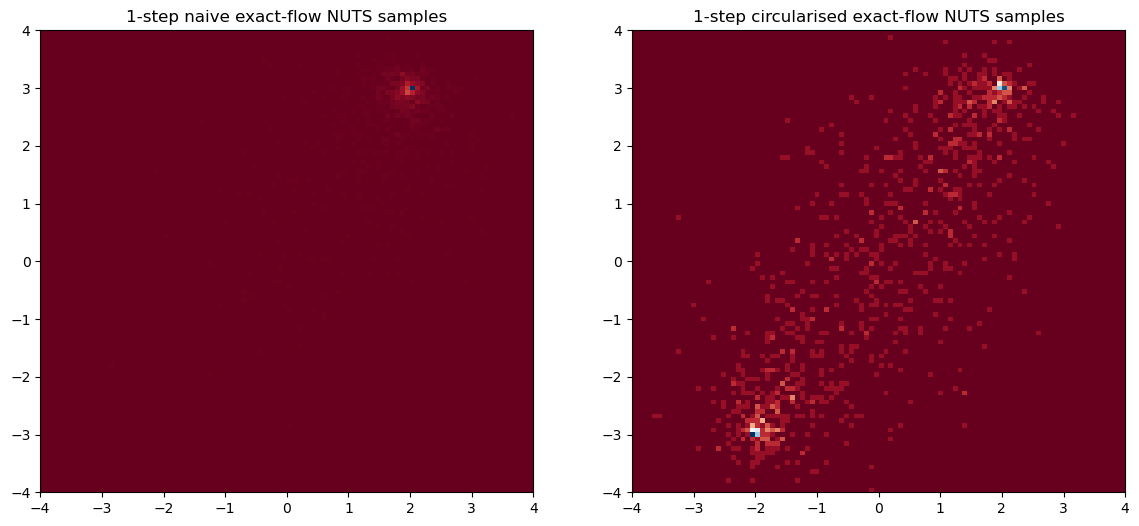

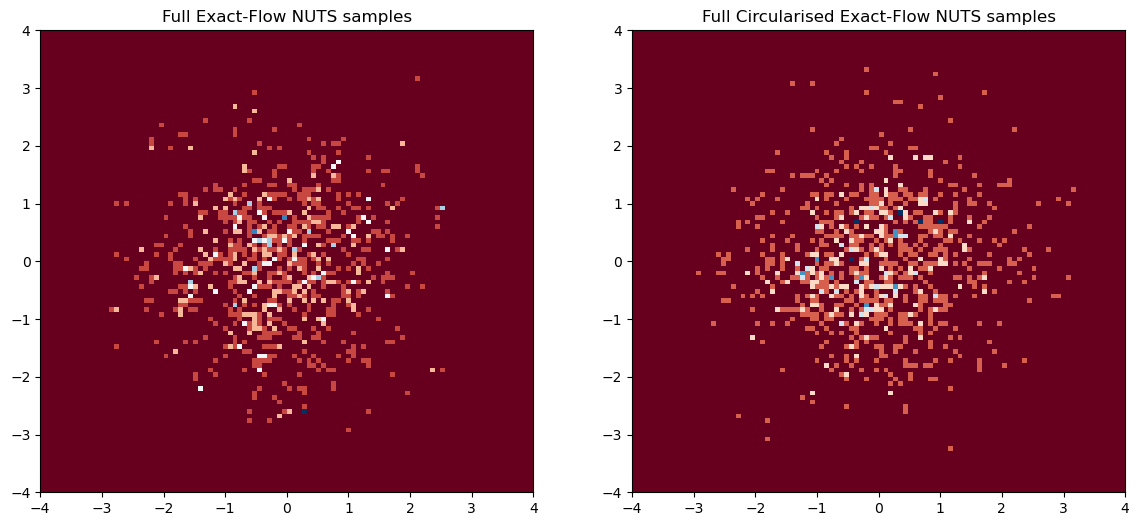

In [9]:
naive_para = {
    "A": None,
    "Sigma": np.eye(2),
    "epsilon": 0.1
}

circ_para = {
    "d": 2,
    "sigma": 1.0,
    "epsilon": 0.1,
    "m": 1.0,
    "eta": 1.0
}

n_samples = 1000
x0 = np.array([2.0, 3.0])

plot_sampler_eval(focus="1-step", x0=x0, naive_para=naive_para, circ_para=circ_para, 
                  n_samples=n_samples, burn_in=0, max_depth=20)
plot_sampler_eval(focus="full", x0=x0, naive_para=naive_para, circ_para=circ_para, 
                  n_samples=n_samples, burn_in=0, max_depth=20)

In [ ]:
# naive_samples = sampler_eval(method="naive", focus="1-step", x0=np.array([0.0, 0.0]), 
#                              naive_para=naive_para, circ_para=None,
#                              n_samples=int(1e5), max_depth=20)
# burn_in = 0

# naive_x = naive_samples[burn_in:, 0]
# naive_y = naive_samples[burn_in:, 1]

# plt.figure(figsize=(6, 6))
# plt.hist2d(naive_x, naive_y, bins=100, range=[[-4, 4], [-4, 4]], cmap='RdBu', density=True)
# plt.title("1-step naive exact-flow NUTS samples")
# plt.show()

# import seaborn as sns
# sns.kdeplot(x=naive_x, y=naive_y, fill=True, 
#                     thresh=0.05, alpha=0.8, cmap='plasma',
#                     cbar=True, cbar_kws={'label': 'Sample Density'},
#                     warn_singular=False)
# plt.xlabel('Position direction 1')
# plt.ylabel('Position direction 2')
# # plt.title(f'KDE of {num_iter} instant jumps from {theta0}')
# plt.axis('equal')
# plt.tight_layout()
# plt.show()

---

Evaluate the expected number of successful doublings/tree depth before the first observed U-turn.

In [10]:
def estimate_EK_T_by_simulation_MultiD_comparison(x0, sigma,
    epsilon=0.1,
    n_rep=1000,
    seed=0,
    m=1.0,
    eta=1.0,
    max_depth=20,
    rank_rtol=1e-12,
    max_attempt_factor=20
):
    """
    Estimate E[K* | x0] and E[T_obs | x0], and compare results by using the circularised
    exact-flow NUTS endpoint criterion and the naive NUTS endpoint criterion.

    Exact circularisation requires rank(Z0)=2, where
        Z0=(x0, sigma p0).
    Hence x0=0 is excluded. For nonzero x0 and Gaussian p0 in d>=2,
    exact collinearity occurs with probability zero. Numerically nearly
    collinear draws are resampled.

    Parameters
    ----------
    x0 : np.ndarray, shape (d,)
        Initial position.
    sigma : float, optional
        Target standard deviation, so Sigma = sigma^2 I_d.
    epsilon : float, optional
        Exact-flow grid spacing, stepsize.
    n_rep : int, optional
        Number of independent repetitions to estimate E[K* | x0] and E[T_obs | x0].
    seed : int, optional
        Random seed for reproducibility.    
    m : float, optional
        Squared radius of the transformed circle.
    eta : float, optional
        Positive weight on the orthogonal complement of span{x0,p0}.
    max_depth : int, optional
        Maximum tree depth for the NUTS sampler.
    rank_rtol : float, optional
        Relative tolerance for detecting nearly singular G.
    max_attempt_factor : int, optional
        Maximum number of attempts to draw a valid p0 before giving up.
    
    """
    x0 = np.asarray(x0, dtype=float)

    if x0.ndim != 1:
        raise ValueError("x0 must be one-dimensional.")
    if np.linalg.norm(x0) == 0:
        raise ValueError(
            "Exact circularisation is undefined at x0=0 because "
            "Z0=(x0, sigma p0) has rank one. Use strictly positive radii."
        )
    if n_rep <= 0:
        raise ValueError("n_rep must be positive.")

    rng = np.random.default_rng(seed)
    d = x0.size

    sampler_naive = ExactFlowNUTS_MultiD_Gaussian(
        Sigma=sigma**2 * np.eye(d),
        epsilon=epsilon,
        rng=rng,
        tol=1e-12
    )

    sampler_circularised = ExactFlowNUTS_MultiD_Gaussian_Circularised(
        d=d,
        sigma=sigma,
        epsilon=epsilon,
        m=m,
        eta=eta,
        rng=rng,
        rank_rtol=rank_rtol,
    )

    K_values_naive = np.empty(n_rep, dtype=float)
    K_values_circularised = np.empty(n_rep, dtype=float)
    T_obs_values_naive = np.empty(n_rep, dtype=float)
    T_obs_values_circularised = np.empty(n_rep, dtype=float)

    accepted = 0
    attempts = 0
    max_attempts = max_attempt_factor * n_rep

    while accepted < n_rep:
        attempts += 1
        if attempts > max_attempts:
            raise RuntimeError(
                "Too many nearly rank-deficient momentum draws. "
                "Increase the smallest radius or reduce rank_rtol."
            )

        p0 = rng.normal(size=d)

        try:
            out_naive = sampler_naive.one_tree(
                x0=x0,
                p0=p0,
                max_depth=max_depth,
                return_sample=False
            )
            out_circularised = sampler_circularised.one_tree(
                x0=x0,
                p0=p0,
                max_depth=max_depth,
                return_sample=False
            )
        except np.linalg.LinAlgError:
            # Exact collinearity has probability zero; this handles only numerically nearly collinear draws.
            continue

        K_values_naive[accepted] = out_naive["K_star"]
        K_values_circularised[accepted] = out_circularised["K_star"]
        T_obs_values_naive[accepted] = out_naive["T_obs"]
        T_obs_values_circularised[accepted] = out_circularised["T_obs"]
        accepted += 1

    naive_mean_esti_K = K_values_naive.mean()
    circularised_mean_esti_K = K_values_circularised.mean()
    naive_mean_esti_T = np.nanmean(T_obs_values_naive)
    circularised_mean_esti_T = np.nanmean(T_obs_values_circularised)

    return naive_mean_esti_K, circularised_mean_esti_K, naive_mean_esti_T, circularised_mean_esti_T

In [11]:
# ============================================================
# Plot E[K* | x0] against |x0|
# ============================================================

def EK_T_by_simulation_MultiD_comparison(scale_vals, direction, sigma, epsilon, n_rep, m, eta):
    """
    Estimate E[K* | x0] and E[T_obs | x0] for multiple x0 norms along a fixed direction.
    Comparison between the circularised NUTS and naive NUTS.

    Parameters
    ----------
    scale_vals : array-like
        Array of norms for x0.

    direction : array-like
        Unit vector specifying the direction of x0.

    sigma : float
        Standard deviation of the isotropic Gaussian target.

    epsilon : float
        Step size for the NUTS simulation.

    n_rep : int
        Number of repetitions for each x0 to estimate E[K* | x0].

    m : float
        Squared radius of the transformed circle.

    eta : float
        Positive weight on the orthogonal complement of span{x0, p0}.

    Returns
    -------
    EK_sim : np.ndarray
        Estimated E[K* | x0] for each norm in scale_vals.

    varK_sim : np.ndarray
        Estimated variance of K* for each norm in scale_vals.

    SE_sim : np.ndarray
        Estimated Monte Carlo standard error for each norm in scale_vals.
    """ 

    EK_sim_naive = []
    EK_sim_circularised = []
    T_obs_sim_naive = []
    T_obs_sim_circularised = []
    # varK_sim = []
    # SE_sim = []

    # Use common random numbers across radii to expose the predicted flat curve.
    for i, scale in enumerate(scale_vals):
        naive_mean_esti_K, circularised_mean_esti_K, naive_mean_esti_T, circularised_mean_esti_T = estimate_EK_T_by_simulation_MultiD_comparison(
            x0=float(scale) * direction,
            sigma=sigma,
            epsilon=epsilon,
            n_rep=n_rep,
            seed=0,  # common random numbers across radii
            m=m,
            eta=eta
        )
        EK_sim_naive.append(naive_mean_esti_K)
        EK_sim_circularised.append(circularised_mean_esti_K)
        T_obs_sim_naive.append(naive_mean_esti_T)
        T_obs_sim_circularised.append(circularised_mean_esti_T)
        # varK_sim.append(var_esti)
        # SE_sim.append(se)

    EK_sim_naive = np.array(EK_sim_naive)
    EK_sim_circularised = np.array(EK_sim_circularised)
    T_obs_sim_naive = np.array(T_obs_sim_naive)
    T_obs_sim_circularised = np.array(T_obs_sim_circularised)
    # varK_sim = np.array(varK_sim)
    # SE_sim = np.array(SE_sim)

    return EK_sim_naive, EK_sim_circularised, T_obs_sim_naive, T_obs_sim_circularised

In [12]:
def plot_MC_estimate_K_and_Tobs_comparison(scale_vals, directions, sigma, epsilon, n_rep, m, eta):

    # def matrix_to_latex(Sigma, decimals=3):
    #     Sigma = np.asarray(Sigma)
    #     rows = []
    #     for row in Sigma:
    #         row_str = ",".join(f"{v:.{decimals}g}" for v in row)
    #         rows.append(row_str)
    #     return r"\left[" + r";\, ".join(rows) + r"\right]"

    # Sigma = sigma**2 * np.eye(len(directions[0]))  # isotropic Gaussian covariance
    # Sigma_latex = matrix_to_latex(Sigma)

    # Store results so we do not run the simulations twice
    results = []

    for direction in directions:
        EK_sim_naive, EK_sim_circularised, T_obs_sim_naive, T_obs_sim_circularised = EK_T_by_simulation_MultiD_comparison(
            scale_vals=scale_vals,
            direction=direction,
            sigma=sigma,
            epsilon=epsilon,
            n_rep=n_rep,
            m=m,
            eta=eta
        )

        direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"

        results.append({
            "direction": direction,
            "direction_str": direction_str,
            "EK_sim_naive": EK_sim_naive,
            "EK_sim_circularised": EK_sim_circularised,
            "T_obs_sim_naive": T_obs_sim_naive,
            "T_obs_sim_circularised": T_obs_sim_circularised
        })

    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0], for both circularised and naive NUTS
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))

    for i, res in enumerate(results):
        plt.plot(
            scale_vals,
            res["EK_sim_naive"],
            label=f"direction {i+1} (naive)"
        )
        plt.plot(
            scale_vals,
            res["EK_sim_circularised"],
            label=f"direction {i+1} (circularised)",
            linestyle="--"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0], for both circularised and naive NUTS
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))

    for i, res in enumerate(results):
        plt.plot(
            scale_vals,
            res["T_obs_sim_naive"],
            label=f"direction {i+1} (naive)"
        )
        plt.plot(
            scale_vals,
            res["T_obs_sim_circularised"],
            label=f"direction {i+1} (circularised)",
            linestyle="--"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

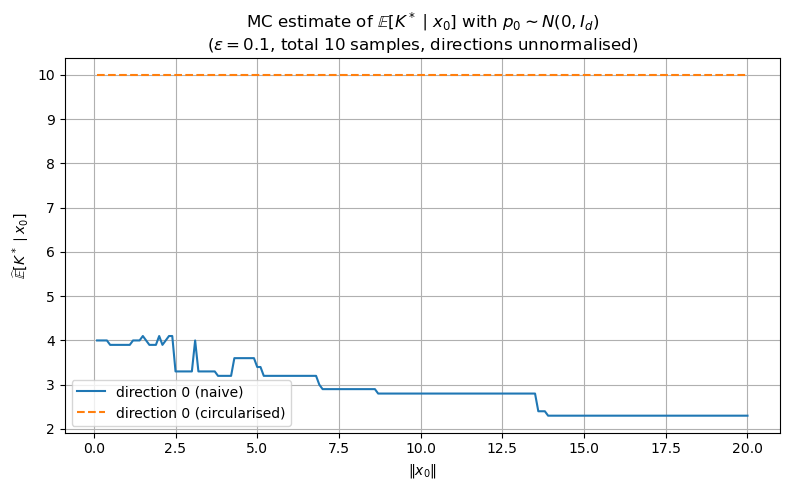

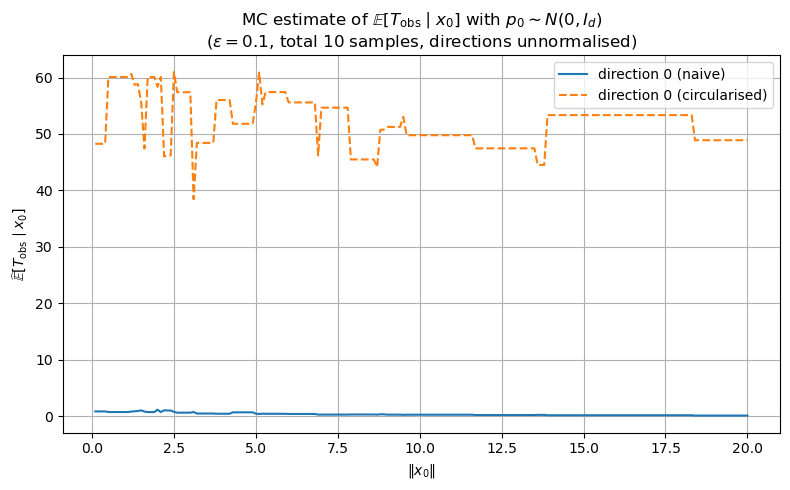

In [ ]:
directions = [
    np.array([1.0, 0.0])
]

sigma = 1.0
epsilon = 0.1
m = 1.0
eta = 1.0

# x0=0 must be excluded: exact circularisation requires rank(Z0)=2.
# This modest grid/repetition count is intended as a quick notebook check.
# Increase them only after confirming the implementation.
scale_vals = np.linspace(0.1, 20, 200)

plot_MC_estimate_K_and_Tobs_comparison(
    scale_vals,
    directions,
    sigma,
    epsilon,
    n_rep=100,
    m=m,
    eta=eta
)

----

# Trajectory study for the circularised NUTS

What is the role for $m$ for controlling the radius? Is this related to $(x_0,p_0)$ for better performance?